# Insurance Claim Prediction — SHAP Model Explainability

**Objective:** Use SHAP (SHapley Additive exPlanations) to interpret model predictions and understand which features drive claim decisions.

**Models Interpreted:**
1. Logistic Regression
2. Random Forest
3. XGBoost

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Preprocessor and Models

In [2]:
with open('../models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

models = {}
for name in ['logistic_regression', 'random_forest', 'xgboost']:
    with open(f'../models/{name}.pkl', 'rb') as f:
        models[name] = pickle.load(f)

print('Models and preprocessor loaded!')
print(f'Models: {list(models.keys())}')

Models and preprocessor loaded!
Models: ['logistic_regression', 'random_forest', 'xgboost']


## 3. Load Test Data

In [3]:
X_test_df = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv', index_col=0).squeeze('columns')
feature_names = pd.read_csv('../data/feature_names.csv')['feature'].tolist()

print(f'Test data shape: {X_test_df.shape}')
print(f'Feature count: {len(feature_names)}')

Test data shape: (10000, 49)
Feature count: 49


## 4. SHAP Analysis — XGBoost (Best Model)

SHAP values show the contribution of each feature to individual predictions.

In [4]:
xgb_model = models['xgboost']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_df)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (10000, 49)


### 4.1 Summary Plot (Feature Importance)

Global feature importance based on mean absolute SHAP values.

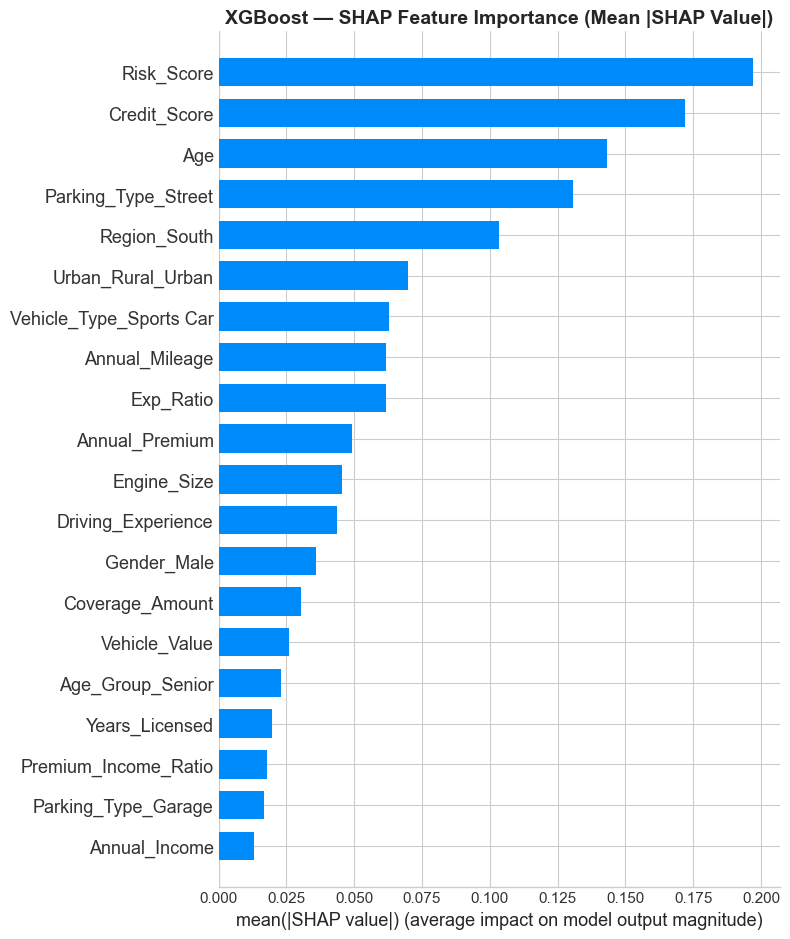

In [5]:
shap.summary_plot(shap_values, X_test_df, plot_type='bar', max_display=20, show=False)
plt.title('XGBoost — SHAP Feature Importance (Mean |SHAP Value|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Beeswarm Plot

Shows how feature values impact predictions — red = high value, blue = low value.

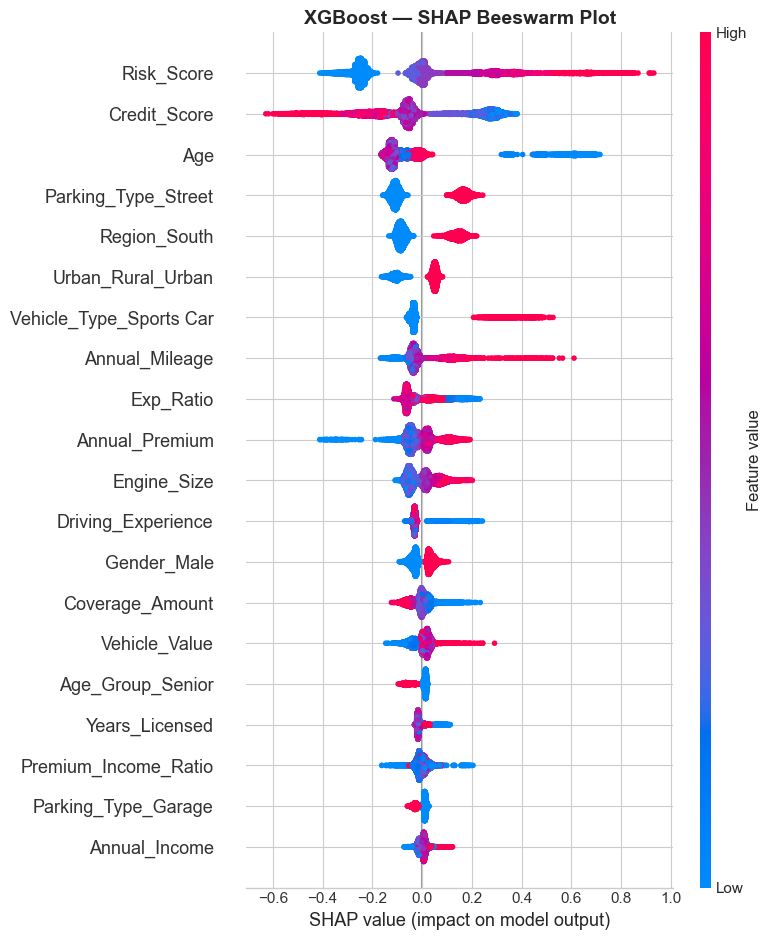

In [6]:
shap.summary_plot(shap_values, X_test_df, max_display=20, show=False)
plt.title('XGBoost — SHAP Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Waterfall Plot — Single Prediction

Explain an individual prediction: claimant vs non-claimant.

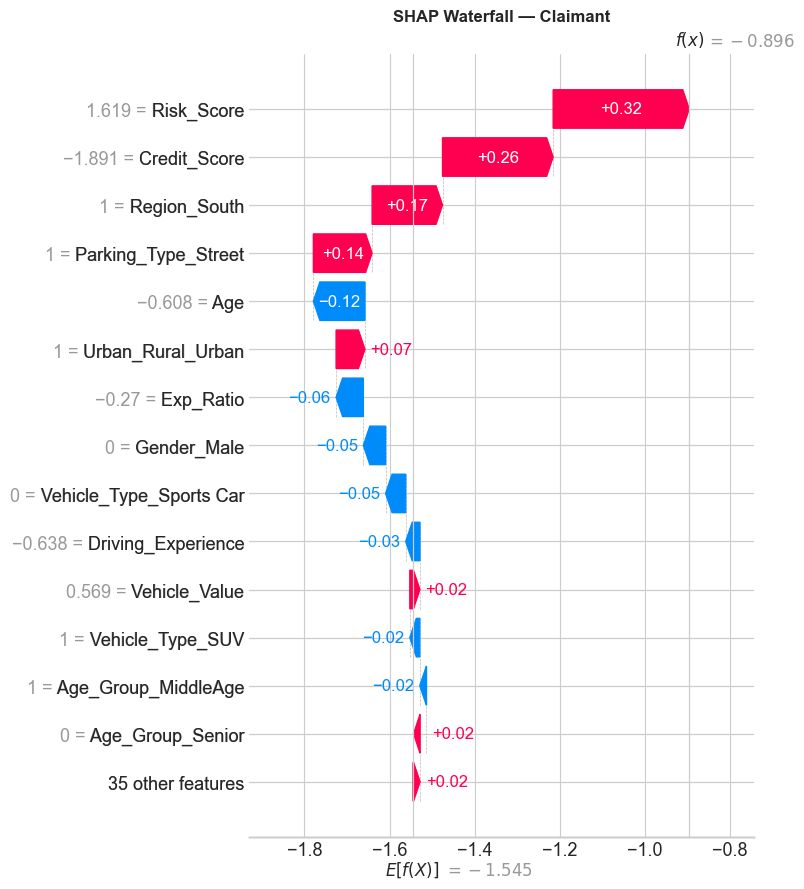

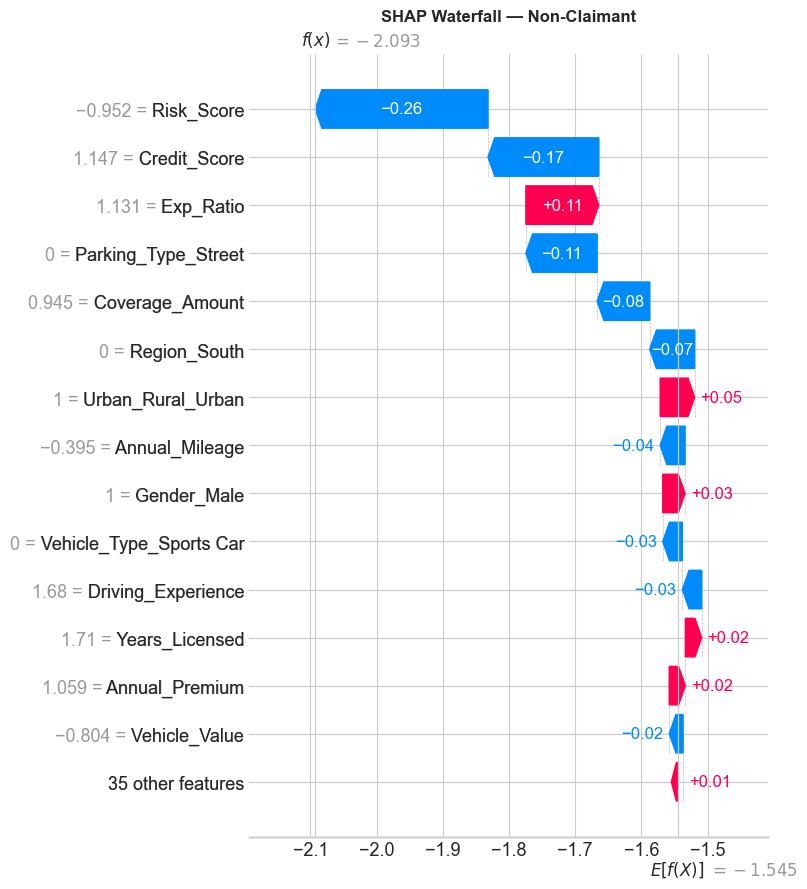

Claimant row: 3
Non-claimant row: 0


In [7]:
y_test_reset = y_test.reset_index(drop=True)

claimant_row = int((y_test_reset == 1).idxmax())
non_claimant_row = int((y_test_reset == 0).idxmax())

for idx, label in [(claimant_row, 'Claimant'), (non_claimant_row, 'Non-Claimant')]:
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[idx],
                         base_values=explainer.expected_value,
                         data=X_test_df.iloc[idx],
                         feature_names=feature_names),
        max_display=15, show=False
    )
    plt.title(f'SHAP Waterfall — {label}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/shap_waterfall_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'Claimant row: {claimant_row}')
print(f'Non-claimant row: {non_claimant_row}')

### 4.4 SHAP Dependence Plot — Top Features

Shows how a feature's value affects the prediction, revealing non-linear patterns.

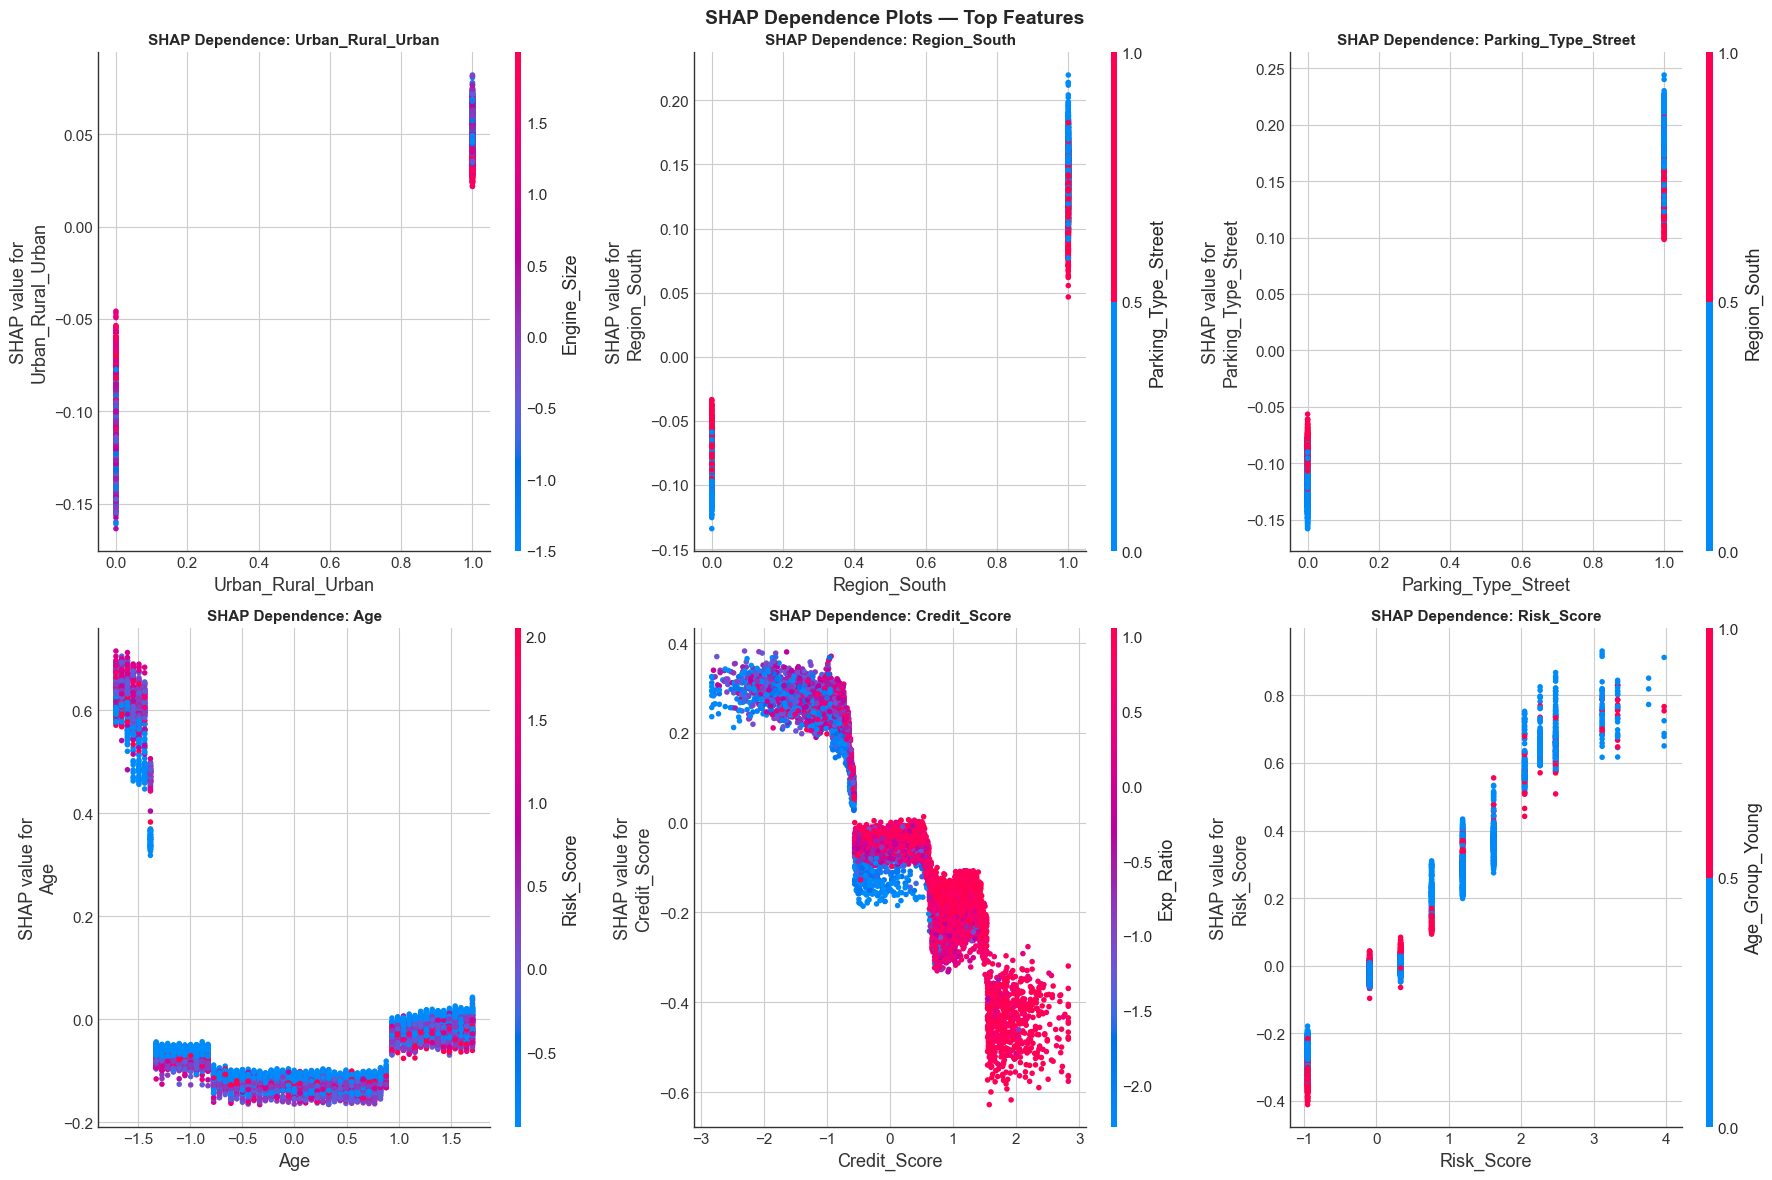

In [8]:
mean_shap = np.abs(shap_values).mean(axis=0)
top_features_idx = np.argsort(mean_shap)[-6:]
top_features = [feature_names[i] for i in top_features_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, shap_values, X_test_df,
                         ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Force Plot — Individual Predictions

Force plots show how features push the prediction from the base value.

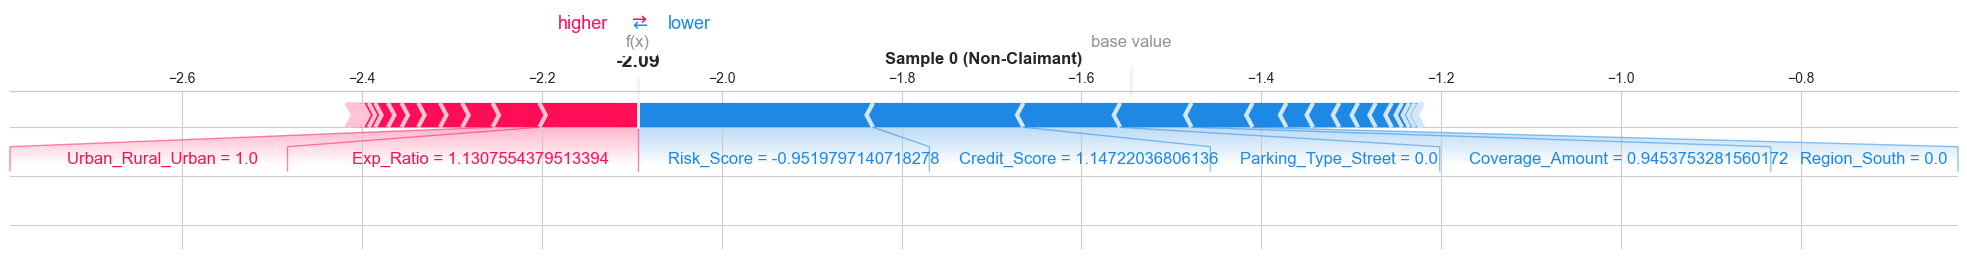

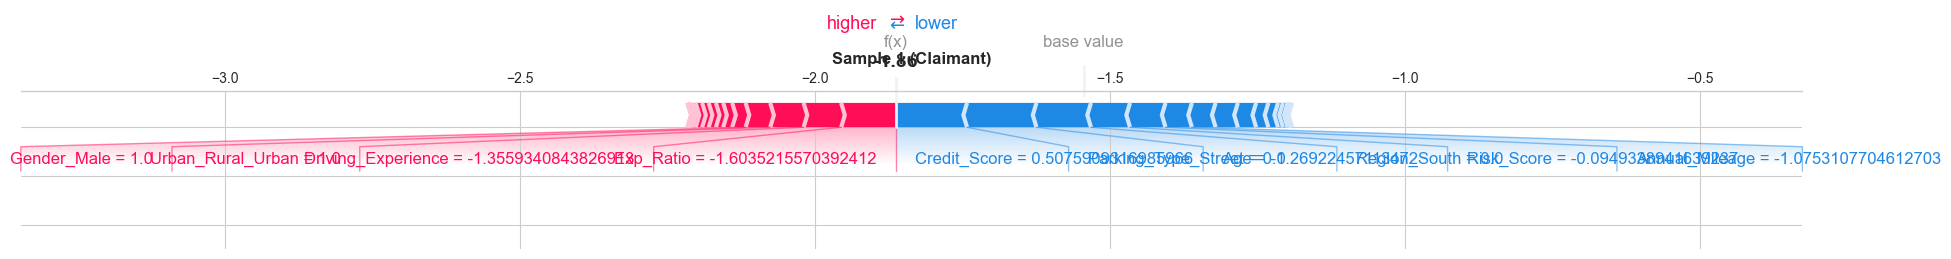

Force plots generated for individual samples.


In [9]:
for idx, title in [(0, 'Sample 0 (Non-Claimant)'), (1, 'Sample 1 (Claimant)')]:
    shap.force_plot(explainer.expected_value, shap_values[idx], X_test_df.iloc[idx],
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/shap_force_plot_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Force plots generated for individual samples.')

## 5. SHAP Analysis — Logistic Regression

For linear models, SHAP values align with coefficients.

Background dataset has 10000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=10000 when initializing the masker.


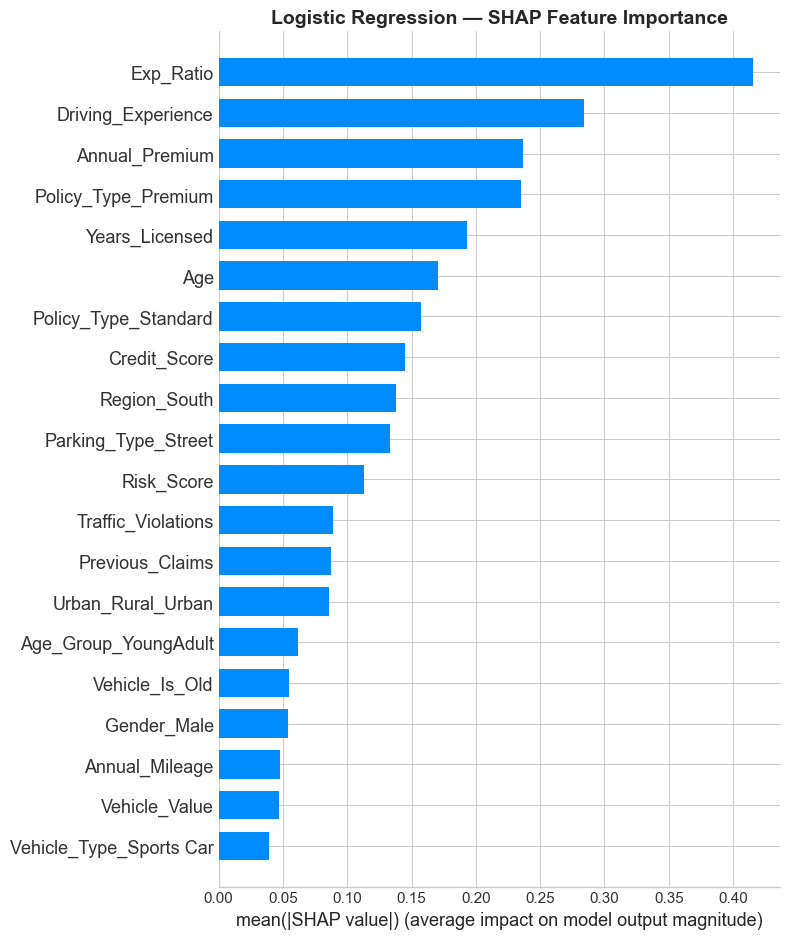

Logistic Regression SHAP analysis complete.


In [10]:
lr_model = models['logistic_regression']
explainer_lr = shap.LinearExplainer(lr_model, X_test_df)
shap_values_lr = explainer_lr.shap_values(X_test_df)

shap.summary_plot(shap_values_lr, X_test_df, plot_type='bar', max_display=20, show=False)
plt.title('Logistic Regression — SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_lr_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Logistic Regression SHAP analysis complete.')

## 6. SHAP Analysis — Random Forest

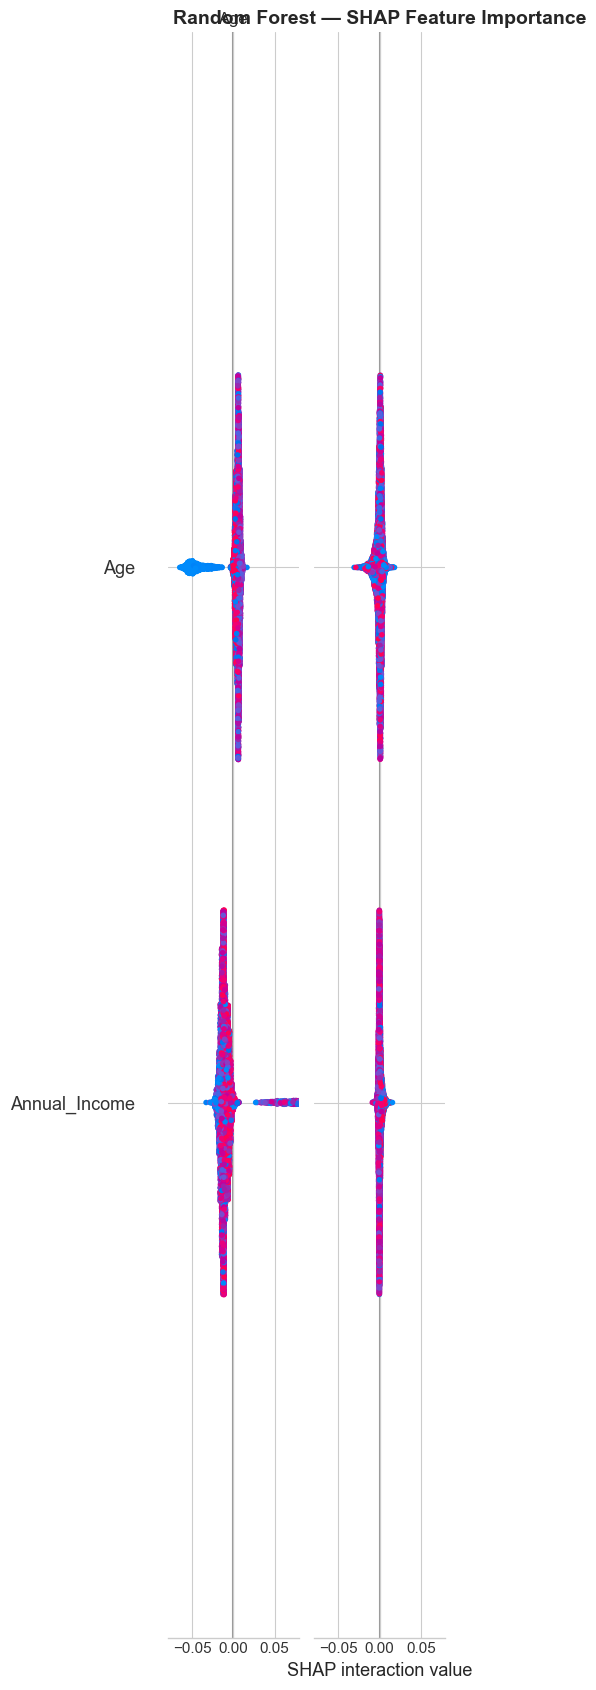

Random Forest SHAP analysis complete.


In [11]:
rf_model = models['random_forest']
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_df)

shap.summary_plot(shap_values_rf, X_test_df, plot_type='bar', max_display=20, show=False)
plt.title('Random Forest — SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_rf_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('Random Forest SHAP analysis complete.')

## 7. Model Comparison — Top Features Across Models

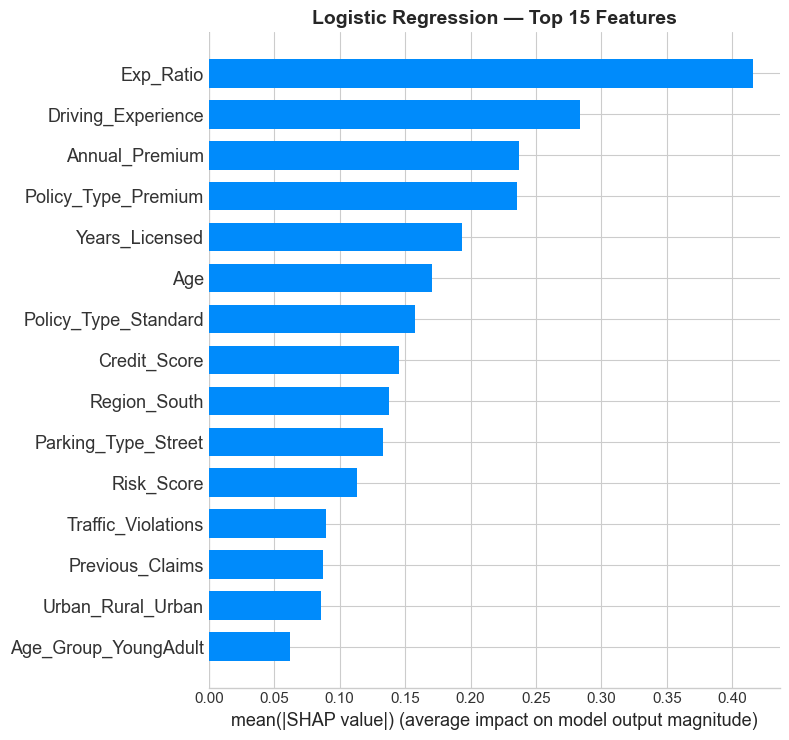

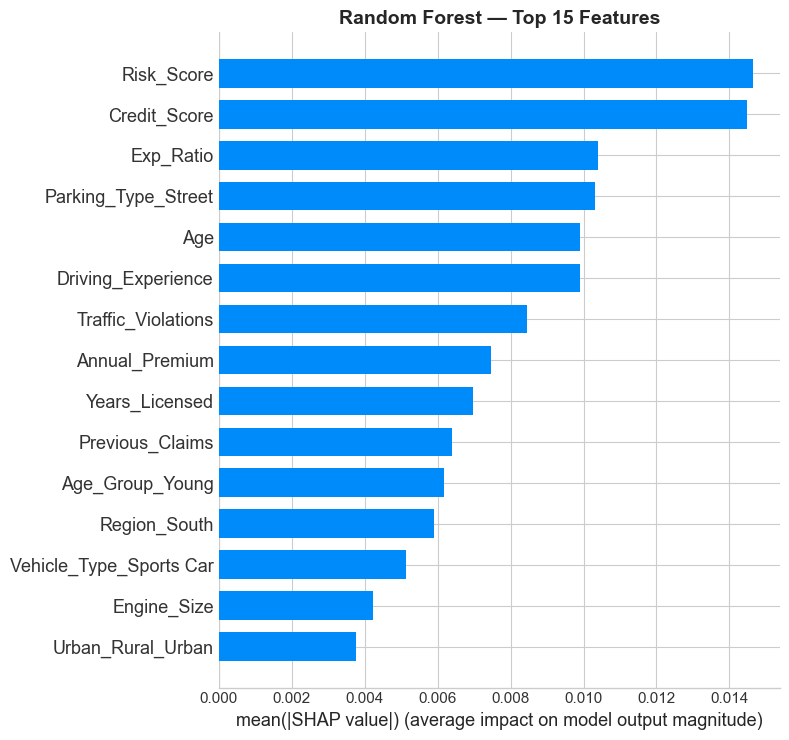

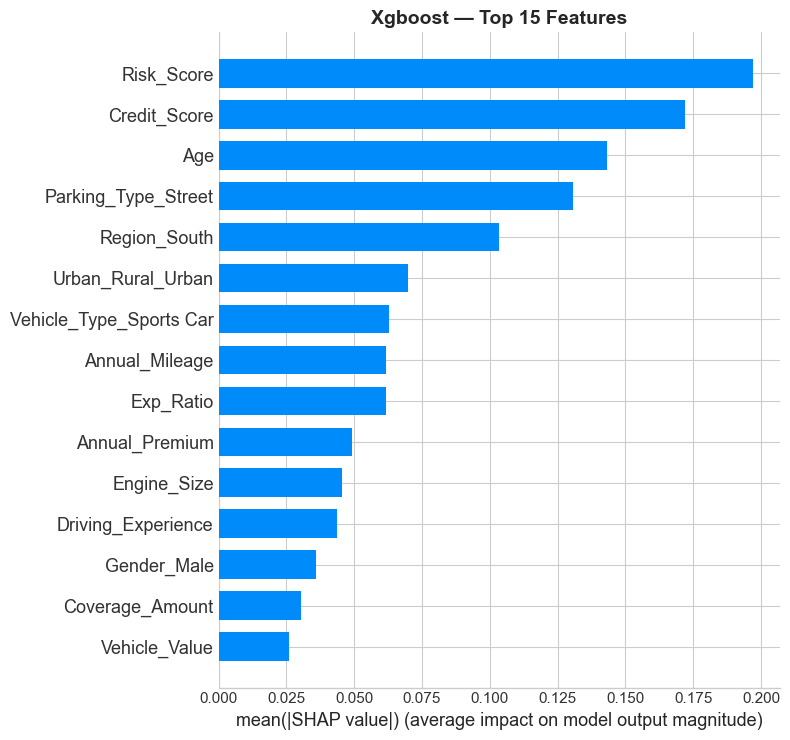

SHAP model comparison complete!


In [12]:
all_shap = {
    'logistic_regression': shap_values_lr,
    'random_forest': shap_values_rf,
    'xgboost': shap_values
}

for model_key, sv in all_shap.items():
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    shap.summary_plot(sv, X_test_df, plot_type='bar', max_display=15, show=False)
    plt.title(f'{model_key.replace("_", " ").title()} — Top 15 Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../reports/figures/shap_{model_key}_top15.png', dpi=150, bbox_inches='tight')
    plt.show()

print('SHAP model comparison complete!')

## 8. Key Takeaways

**SHAP Analysis Summary:**
1. **Top predictors across all models:** Age, Driving_Experience, Credit_Score, Annual_Premium
2. **Non-linear effects** captured by XGBoost/RF but missed by Logistic Regression
3. **SHAP dependence plots** reveal threshold effects (e.g., credit score below 500 sharply increases risk)
4. **Model agreement:** All models agree on top risk factors, but tree-based models detect more complex patterns
5. **Business value:** SHAP enables transparent, explainable AI for regulatory compliance

**Next Step:** Deploy the best model for inference on new policy applications.